# Aztec G-dDT Test Run

In [1]:
import sys
sys.path.append('../../')

import pandas as pd
import os
import plotly.express as px
import seaborn as sns 
import matplotlib.pyplot as plt

import plotly.io as pio
pio.renderers.default = "png"

## Perform Simulation

In [2]:
from aztec_gddt.experiment import test_run

# HACK in order to do sims in single mode
runs = 3
sim_dfs = []
for run in range(runs):
    sim_dfs.append(test_run(N_TIMESTEPS=3000).set_index('l1_blocks_passed').assign(run=run))
mc_traj_df = pd.concat(sim_dfs)

traj_df = mc_traj_df.query("run == 0 & subset == 0 & simulation == 0")
traj_df.columns

Index(['index', 'timestep', 'delta_l1_blocks', 'l2_blocks_passed', 'agents',
       'validator_set', 'current_epoch', 'last_epoch',
       'last_reward_time_in_l1', 'last_reward_to_provers',
       ...
       'SHAPE_E_BLOCK_VALIDATE', 'SCALE_E_BLOCK_VALIDATE',
       'SHAPE_E_BLOCK_SENT', 'SCALE_E_BLOCK_SENT',
       'PROBABILITY_E_EPOCH_FINISH', 'EXPECTED_PROOFS_LAST_EPOCH_PER_TS',
       'EXPECTED_PROOFS_CURRENT_EPOCH_PER_TS',
       'MIN_FRACTION_COMPLETE_PROOF_LAST_EPOCH',
       'MAX_FRACTION_COMPLETE_PROOF_LAST_EPOCH', 'market_price_eth'],
      dtype='object', length=107)

## Visualization over Model Features

In [3]:
traj_df.head(5)

,index,timestep,delta_l1_blocks,l2_blocks_passed,agents,validator_set,current_epoch,last_epoch,last_reward_time_in_l1,last_reward_to_provers,...,SHAPE_E_BLOCK_VALIDATE,SCALE_E_BLOCK_VALIDATE,SHAPE_E_BLOCK_SENT,SCALE_E_BLOCK_SENT,PROBABILITY_E_EPOCH_FINISH,EXPECTED_PROOFS_LAST_EPOCH_PER_TS,EXPECTED_PROOFS_CURRENT_EPOCH_PER_TS,MIN_FRACTION_COMPLETE_PROOF_LAST_EPOCH,MAX_FRACTION_COMPLETE_PROOF_LAST_EPOCH,market_price_eth
l1_blocks_passed,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,"{'prover': Agent(uuid='prover', stake=inf, sco...",{},"Epoch(init_time_in_l1=-999, validators=[], slo...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,0.0,...,2.0,0.333333,2.0,0.1,0.15,1,1,0.6,1.0,3300
1,7,1,1,1,"{'prover': Agent(uuid='prover', stake=inf, sco...",{},"Epoch(init_time_in_l1=1, validators=['27', '79...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,0.0,...,2.0,0.333333,2.0,0.1,0.15,1,1,0.6,1.0,3300
2,14,2,1,1,"{'prover': Agent(uuid='prover', stake=inf, sco...",{},"Epoch(init_time_in_l1=1, validators=['27', '79...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,0.0,...,2.0,0.333333,2.0,0.1,0.15,1,1,0.6,1.0,3300
3,21,3,1,1,"{'prover': Agent(uuid='prover', stake=inf, sco...",{},"Epoch(init_time_in_l1=1, validators=['27', '79...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,0.0,...,2.0,0.333333,2.0,0.1,0.15,1,1,0.6,1.0,3300
4,28,4,1,2,"{'prover': Agent(uuid='prover', stake=inf, sco...",{},"Epoch(init_time_in_l1=1, validators=['27', '79...","Epoch(init_time_in_l1=-999, validators=[], slo...",0,0.0,...,2.0,0.333333,2.0,0.1,0.15,1,1,0.6,1.0,3300


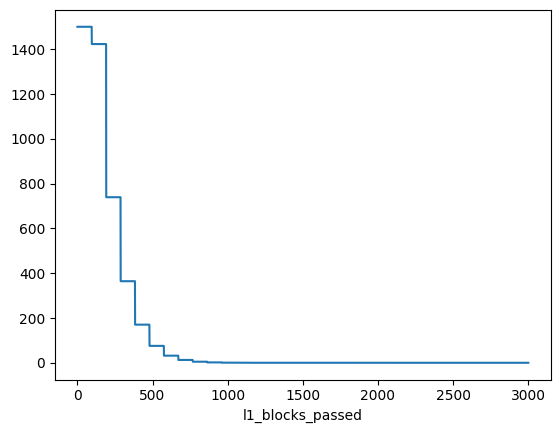

In [4]:
traj_df.last_reward.plot()
plt.show()

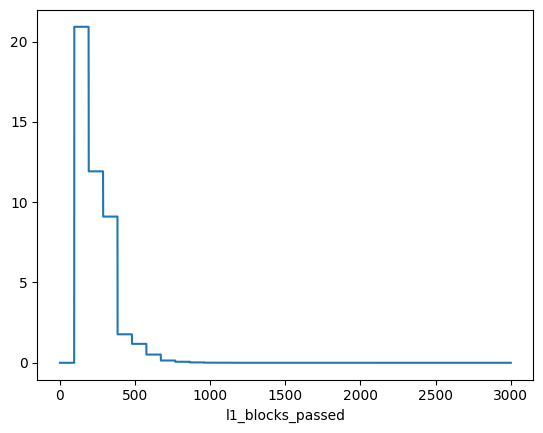

In [5]:
traj_df.last_reward_per_prover.plot()
plt.show()

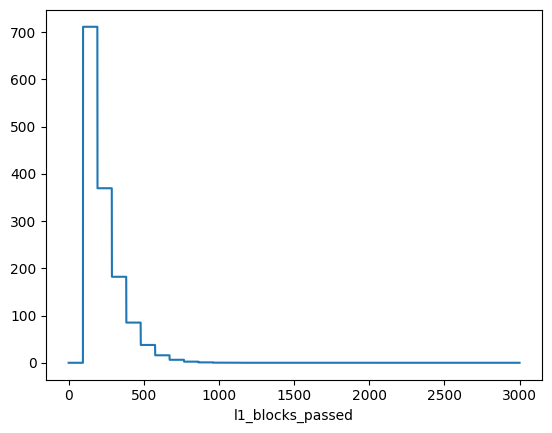

In [6]:
traj_df.last_reward_to_provers.plot()
plt.show()

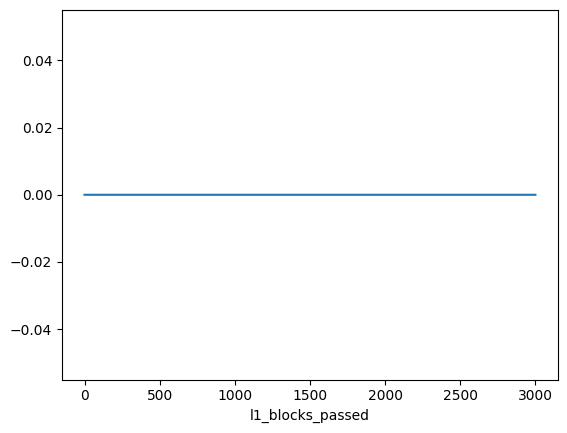

In [7]:
traj_df.slash_count.plot()
plt.show()

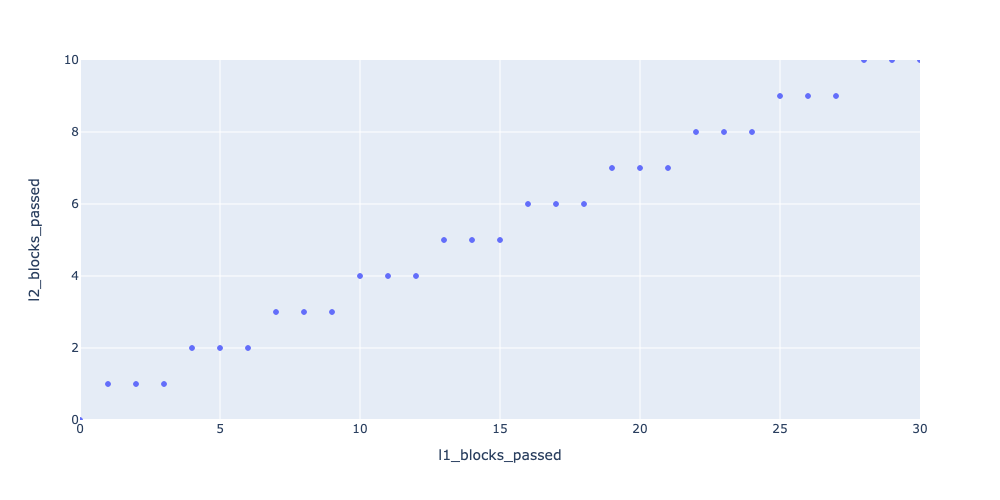

In [8]:
fig = px.scatter(traj_df.reset_index(), 'l1_blocks_passed', 'l2_blocks_passed')
fig.update_layout(yaxis_range=[0, 10], xaxis_range=[0,  10 * 3], width=1000, height=500)
fig.show()

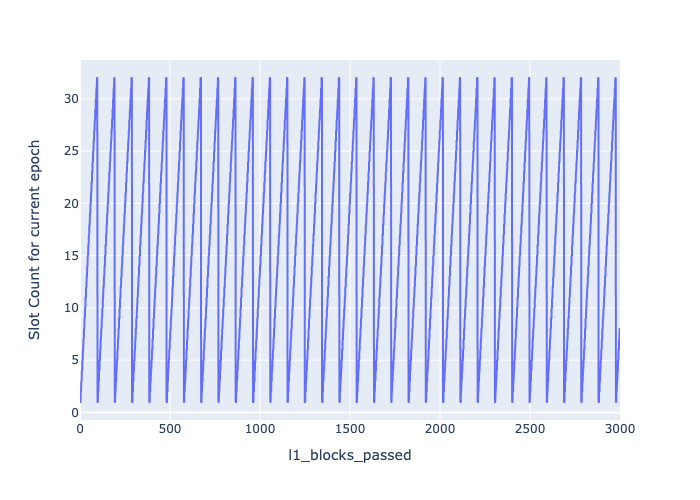

In [9]:
y = traj_df.current_epoch.map(lambda x: len(x.slots))

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Slot Count for current epoch'})
fig.show()

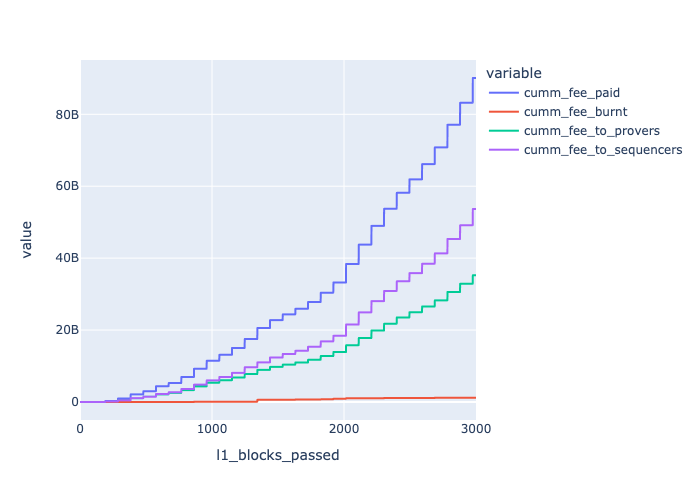

In [10]:
y = ['cumm_fee_paid', 'cumm_fee_burnt', 'cumm_fee_to_provers', 'cumm_fee_to_sequencers']

fig = px.line(traj_df, y=y)
fig.show()

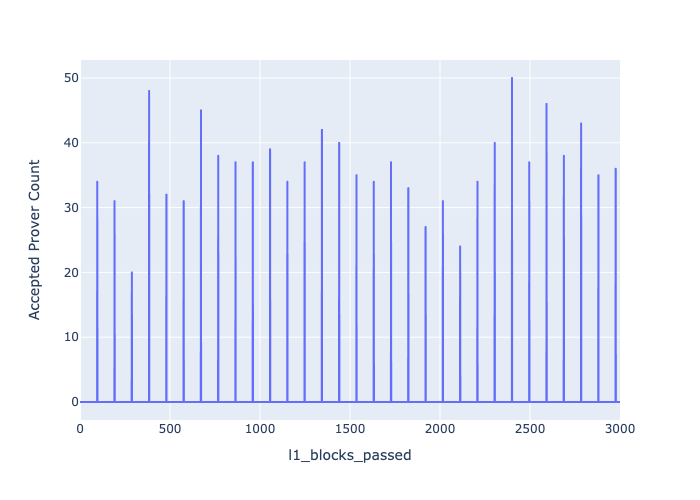

In [11]:
y = traj_df.last_epoch.map(lambda x: len(x.accepted_provers))

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Accepted Prover Count'})
fig.show()

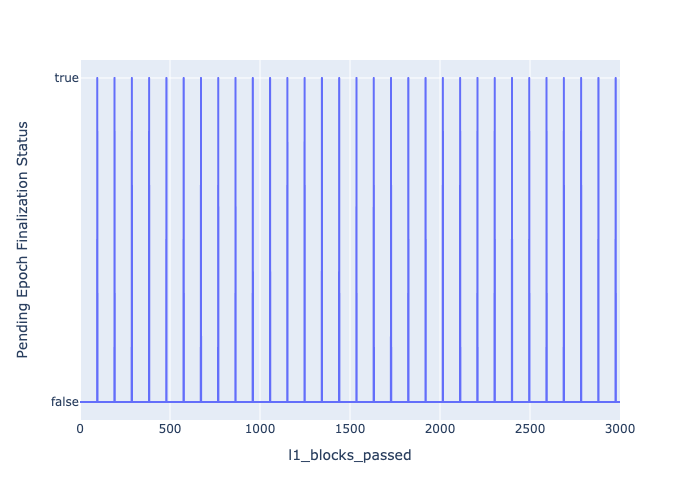

In [12]:
y = traj_df.last_epoch.map(lambda x: x.finalized)

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Pending Epoch Finalization Status'})
fig.show()

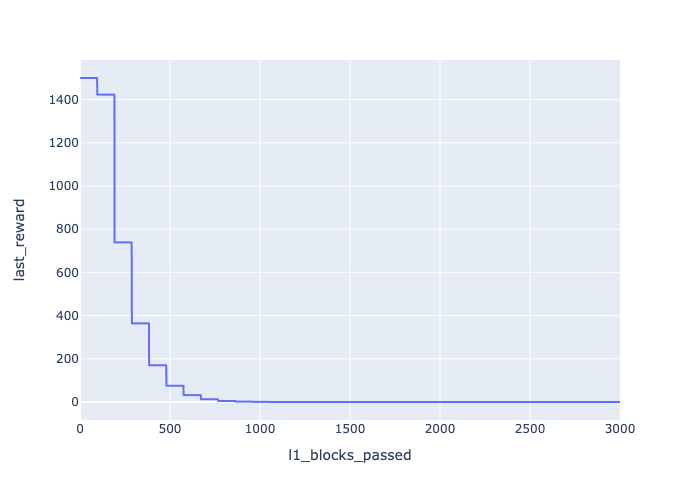

In [13]:
y = traj_df.last_reward

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Last Reward'})
fig.show()

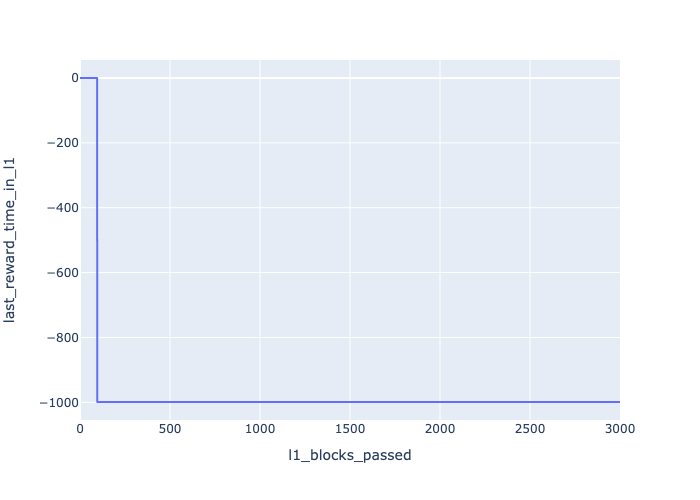

In [14]:
y = traj_df.last_reward_time_in_l1

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Last Reward Time'})
fig.show()

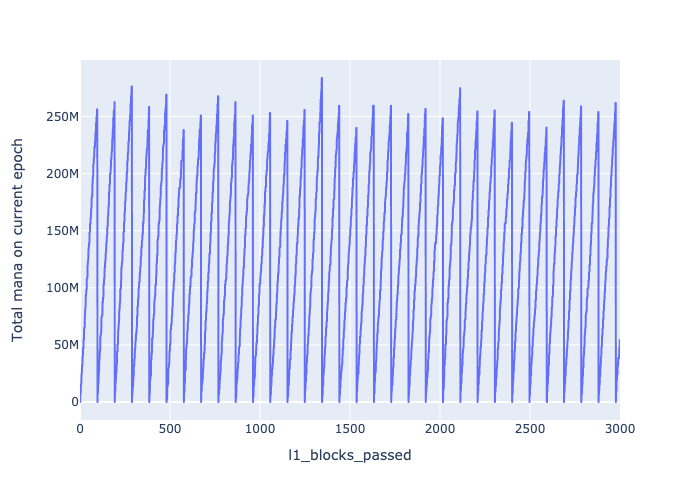

In [15]:
y = traj_df.current_epoch.map(lambda x: sum(s.tx_total_mana for s in x.slots))

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Total mana on current epoch'})
fig.show()

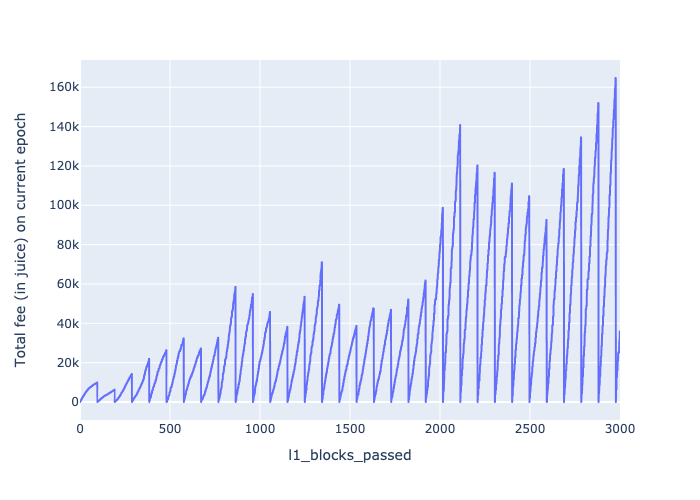

In [16]:
y = traj_df.current_epoch.map(lambda x: sum(s.tx_total_fee for s in x.slots))

fig = px.line(traj_df, y=y, labels={"x": 'timestep', 'y': 'Total fee (in juice) on current epoch'})
fig.show()

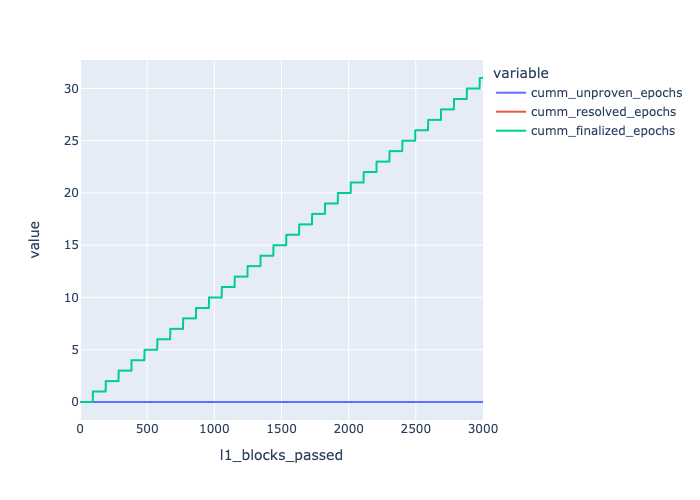

In [17]:
y = ['cumm_unproven_epochs', 'cumm_resolved_epochs', 'cumm_finalized_epochs']

fig = px.line(traj_df, y=y)
fig.show()

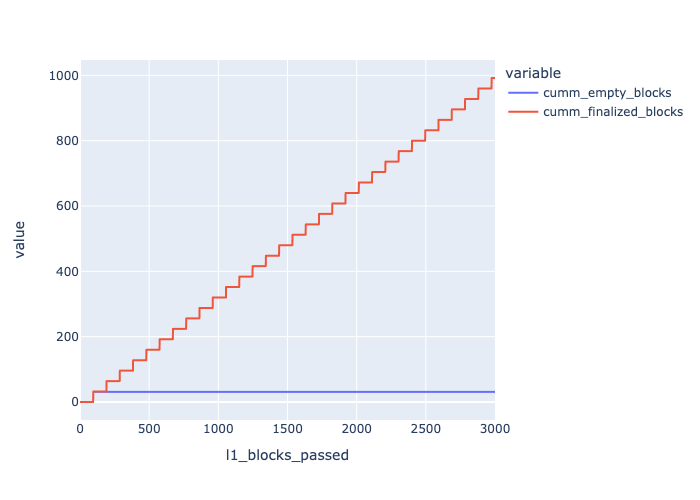

In [18]:
y = ['cumm_empty_blocks', 'cumm_finalized_blocks']

fig = px.line(traj_df, y=y)
fig.show()

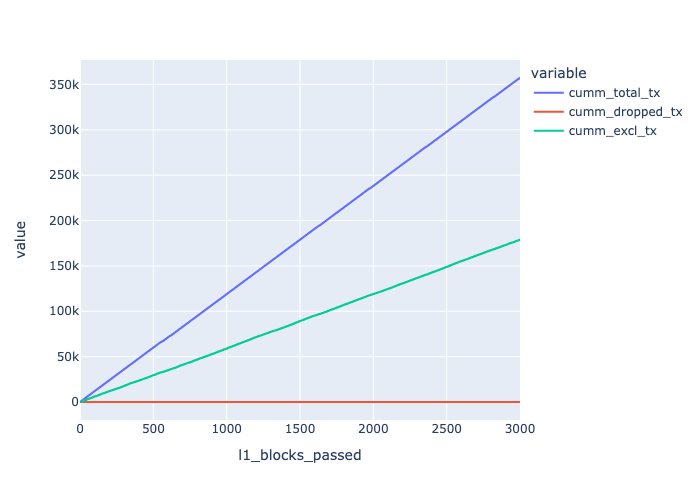

In [19]:
y = ['cumm_total_tx', 'cumm_dropped_tx', 'cumm_excl_tx']

fig = px.line(traj_df, y=y)
fig.show()

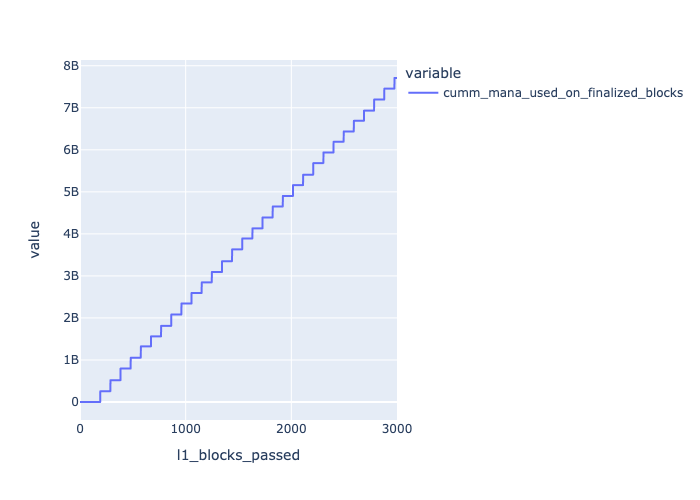

In [20]:
y = ['cumm_mana_used_on_finalized_blocks']

fig = px.line(traj_df, y=y)
fig.show()

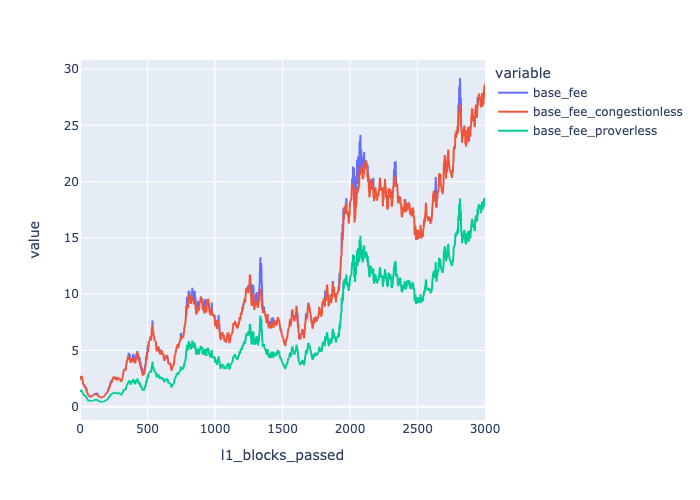

In [21]:
y = ['base_fee', 'base_fee_congestionless', 'base_fee_proverless']

fig = px.line(traj_df, y=y)
fig.show()

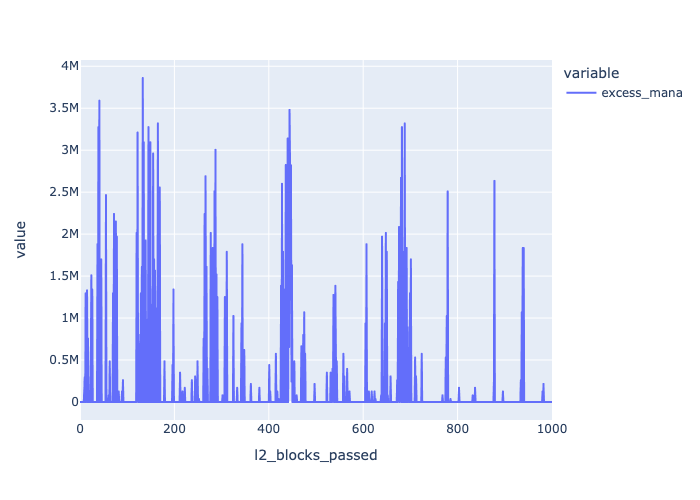

In [22]:
x = 'l2_blocks_passed'
y = ['excess_mana']

fig = px.line(traj_df, x=x, y=y)
fig.show()

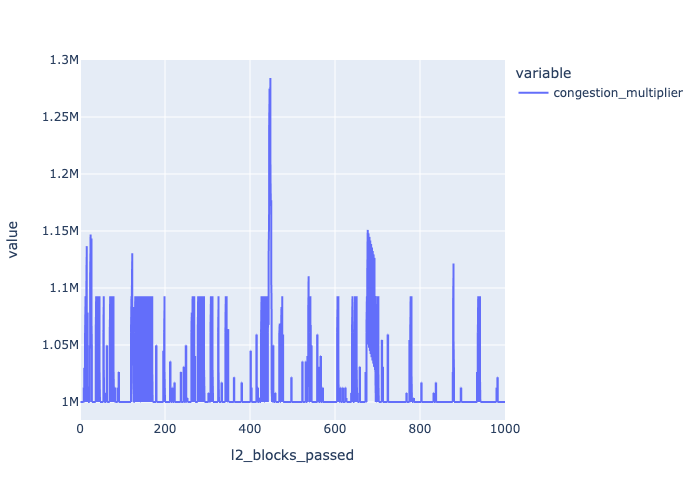

In [23]:
x = 'l2_blocks_passed'
y = ['congestion_multiplier']

fig = px.line(traj_df, x=x, y=y)
fig.show()

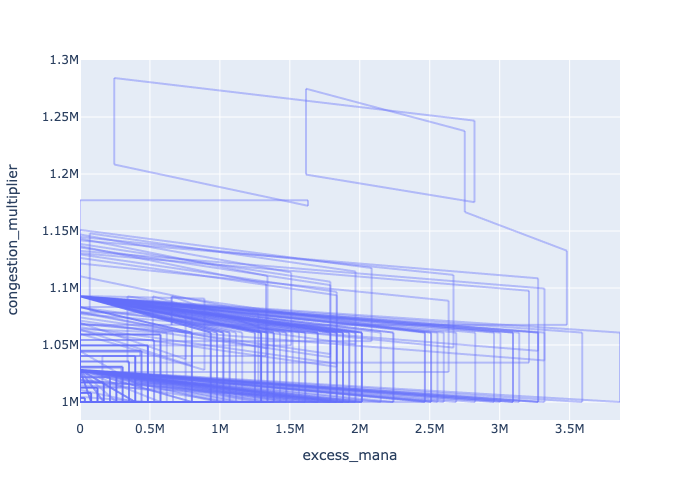

In [24]:

fig = px.line(traj_df, x='excess_mana', y='congestion_multiplier')
fig.update_traces(opacity=.4)
fig.show()

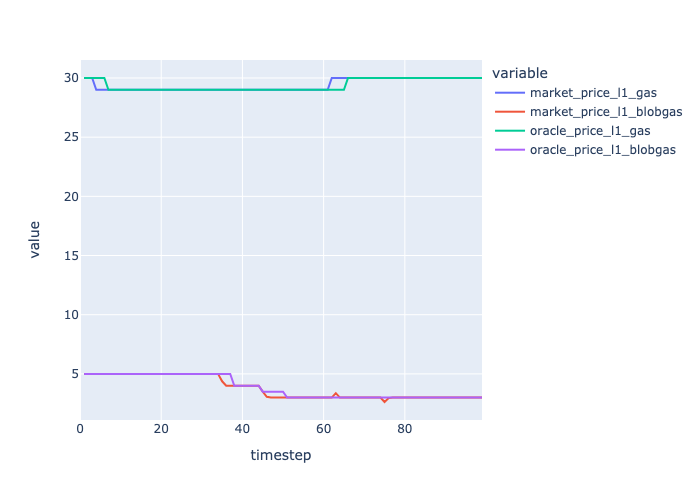

In [25]:
x = 'timestep'
y = ['market_price_l1_gas', 'market_price_l1_blobgas',
      'oracle_price_l1_gas', 'oracle_price_l1_blobgas']

fig = px.line(traj_df.query('timestep < 100'), x=x, y=y)
fig.show()

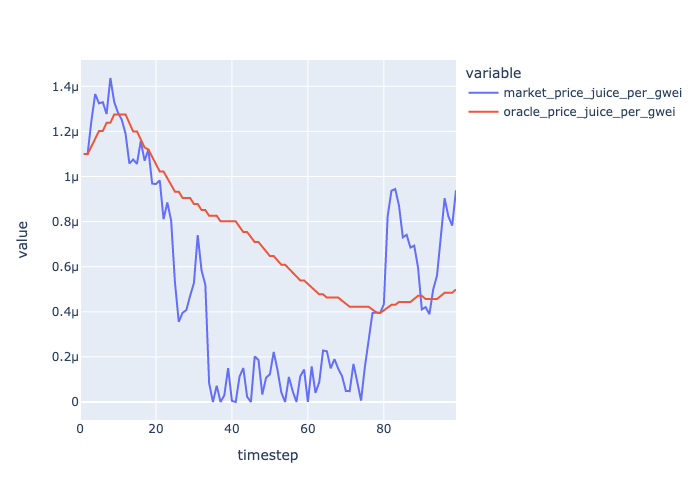

In [26]:
y = ['market_price_juice_per_gwei', 'oracle_price_juice_per_gwei']

fig = px.line(traj_df.query('timestep < 100'), x=x, y=y)
fig.show()

/Users/danlessa/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



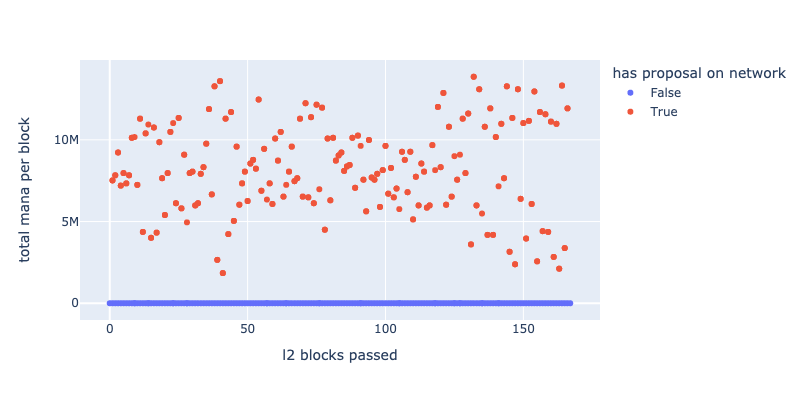

In [27]:

N = 500
x = traj_df.l2_blocks_passed.head(N)
y = traj_df.current_epoch.map(lambda x: x.slots[-1].tx_total_mana).head(N)
c = traj_df.current_epoch.map(
    lambda x: x.slots[-1].has_proposal_on_network).head(N)

fig = px.scatter(
    x=x,
    y=y,
    color=c, labels={
        "x": "l2 blocks passed",
        "y": "total mana per block",
        "color": "has proposal on network"},
    width=800,
    height=400)
fig.show()

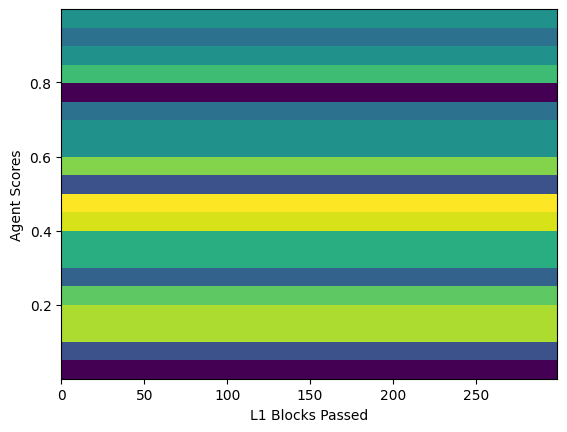

In [28]:
import numpy as np
x = []
y = []
for i, row in traj_df.head(300).iterrows():
    y_lst = [a.score for a in row.agents.values() if np.isfinite(a.score)]
    y += y_lst
    x += len(y_lst) * [i]

plt.hist2d(x, y, bins=(300, 20))
plt.xlabel('L1 Blocks Passed')
plt.ylabel('Agent Scores')
plt.show()

## Visualization over PSUU Per-Trajectory Metrics

In [29]:
from aztec_gddt.analysis.metrics import *

In [30]:
for label, fn in PER_TRAJECTORY_METRICS.items():
    print(f"{label}: {fn.__name__}")
    print(mc_traj_df.reset_index().groupby(['simulation', 'subset', 'run']).apply(fn, include_groups=False))
    print("---")

T-M1: relative_volatility_across_time
simulation  subset  run
0           0       0      3.639440e-07
                    1      5.027017e-07
                    2      4.995028e-07
dtype: float64
---
T-M2: empty_blocks_during_trajectory
simulation  subset  run
0           0       0      31
                    1      31
                    2      31
dtype: int64
---
T-M3: unproven_epochs_during_trajectory
simulation  subset  run
0           0       0      0
                    1      0
                    2      0
dtype: int64
---
T-M4: fraction_dropped_tx_during_trajectory
simulation  subset  run
0           0       0      0.0
                    1      0.0
                    2      0.0
dtype: float64
---
T-M5: fraction_excluded_tx_during_trajectory
simulation  subset  run
0           0       0      0.500664
                    1      0.500510
                    2      0.505626
dtype: float64
---
T-M6: base_fee_rebound_inside_range
simulation  subset  run
0           0       0      

/Users/danlessa/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning:

invalid value encountered in reduce

/Users/danlessa/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning:

invalid value encountered in reduce



In [31]:
for label, fn in PER_TRAJECTORY_GROUP_METRICS.items():

    groups = list(mc_traj_df.reset_index().groupby(['simulation', 'subset']))
    for i, g in groups:
        dfs = [el[1] for el in list(g.groupby('run'))]
        print(f"{label}: {fn.__name__}")
        print(fn(dfs))
        print("---")    

TG-M1: <lambda>
4.553828255073862e-07
---
TG-M2: <lambda>
31.0
---
TG-M3: <lambda>
0.0
---
TG-M4: <lambda>
0.0
---
TG-M5: <lambda>
1.0
---
TG-M6: <lambda>
0.5022663255162135
---
TG-M7: <lambda>
0.6666666666666666
---
TG-M8a: <lambda>
nan
---
TG-M8b: <lambda>
nan
---
TG-M9: <lambda>
inf
---
TG-M10: <lambda>
1.0
---
TG-M12: tg_m12
0.0
---
TG-M13: tg_m13
0.0
---


/Users/danlessa/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning:

invalid value encountered in reduce

/Users/danlessa/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning:

invalid value encountered in reduce

